# Breaking News Signal Detector
**Focus:** Middle East / Geopolitics

- **Phase 1:** RSS Feed Ingestion
- **Phase 2:** Sentence Embedding Similarity (6-hour time window)
- **Phase 3:** Cluster Detection (Louvain community detection)
- **Phase 4:** Signal Scoring
- **Phase 5:** Visualization

In [1]:
# ===== PHASE 1: Install & Import =====
!pip install feedparser sentence-transformers -q

import feedparser
import pandas as pd
from datetime import datetime, timezone
from dateutil import parser as dateparser

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 1.2 MB/s eta 0:00:00


In [2]:
# ===== PHASE 1: Define RSS Sources =====

RSS_FEEDS = {
    "BBC Middle East":     "https://feeds.bbci.co.uk/news/world/middle_east/rss.xml",
    "Guardian Middle East": "https://www.theguardian.com/world/middleeast/rss",
    "Al Jazeera":          "https://www.aljazeera.com/xml/rss/all.xml",
    "Al-Monitor":          "https://www.al-monitor.com/rss",
    "Middle East Eye":     "https://www.middleeasteye.net/rss",
    "NPR World":           "https://feeds.npr.org/1004/rss.xml",
    "Reuters World":       "https://www.reutersagency.com/feed/?taxonomy=best-topics&post_type=best",
}

In [3]:
# ===== PHASE 1: Fetch and Normalize =====

def fetch_feed(outlet_name: str, feed_url: str) -> list[dict]:
    feed = feedparser.parse(feed_url)
    records = []
    for entry in feed.entries:
        pub_date = None
        for date_field in ("published", "updated"):
            raw = getattr(entry, date_field, None)
            if raw:
                try:
                    pub_date = dateparser.parse(raw)
                    break
                except (ValueError, TypeError):
                    continue
        if pub_date is None:
            pub_date = datetime.now(timezone.utc)
        if pub_date.tzinfo is None:
            pub_date = pub_date.replace(tzinfo=timezone.utc)
        records.append({
            "outlet":    outlet_name,
            "title":     entry.get("title", "").strip(),
            "summary":   entry.get("summary", "").strip(),
            "link":      entry.get("link", ""),
            "published": pub_date,
        })
    return records

def fetch_all_feeds(feeds: dict = RSS_FEEDS) -> pd.DataFrame:
    all_records = []
    for name, url in feeds.items():
        try:
            records = fetch_feed(name, url)
            print(f"  ✓ {name}: {len(records)} items")
            all_records.extend(records)
        except Exception as e:
            print(f"  ✗ {name}: {e}")
    df = pd.DataFrame(all_records)
    if not df.empty:
        df = df.sort_values("published", ascending=False).reset_index(drop=True)
    return df

In [4]:
# ===== PHASE 1: Run It =====

print("Fetching Middle East / geopolitics headlines...\n")
headlines = fetch_all_feeds()
print(f"\n— {len(headlines)} total headlines from {headlines['outlet'].nunique()} outlets —")

Fetching Middle East / geopolitics headlines...

  ✓ BBC Middle East: 39 items
  ✓ Guardian Middle East: 20 items
  ✓ Al Jazeera: 25 items
  ✓ Al-Monitor: 20 items
  ✓ Middle East Eye: 20 items
  ✓ NPR World: 10 items
  ✓ Reuters World: 0 items

— 134 total headlines from 6 outlets —


---
## Phase 2: Sentence Embedding Similarity

Instead of TF-IDF (which matches on shared **words**), we use a
sentence transformer model that encodes **meaning**. Two headlines
about the same event will score high even if they use completely
different words — e.g. "Iran mourns supreme leader" and
"Millions attend Khamenei funeral" share almost no vocabulary
but are semantically identical.

In [5]:
# ===== PHASE 2: Load sentence transformer model =====
# all-MiniLM-L6-v2 is small (80MB), fast, and runs on Colab's
# free CPU runtime. It produces 384-dimensional embeddings.
# First run downloads the model; subsequent runs use the cache.

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

model = SentenceTransformer("all-MiniLM-L6-v2")
print(f"Model loaded: all-MiniLM-L6-v2 (384-dim embeddings)")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded: all-MiniLM-L6-v2 (384-dim embeddings)


In [6]:
# ===== PHASE 2: Combine text and encode =====

headlines["text"] = headlines["title"] + " " + headlines["summary"].fillna("")

# Encode all headlines in one batch — takes ~5 seconds on Colab CPU
print("Encoding headlines...")
embeddings = model.encode(
    headlines["text"].tolist(),
    show_progress_bar=True,
    normalize_embeddings=True,  # Pre-normalize so cosine sim = dot product
)

print(f"\nEmbedding matrix: {embeddings.shape}")
print(f"  → {embeddings.shape[0]} headlines")
print(f"  → {embeddings.shape[1]} dimensions per embedding")

Encoding headlines...


Batches:   0%|          | 0/5 [00:00<?, ?it/s]


Embedding matrix: (134, 384)
  → 134 headlines
  → 384 dimensions per embedding


In [7]:
# ===== PHASE 2: Compute cosine similarity =====

sim_matrix = cosine_similarity(embeddings)
np.fill_diagonal(sim_matrix, 0)

print(f"Similarity matrix: {sim_matrix.shape}")
print(f"Max similarity found: {sim_matrix.max():.3f}")

Similarity matrix: (134, 134)
Max similarity found: 1.000


In [8]:
# ===== PHASE 2: Find similar pairs (with time window) =====
# NOTE: With sentence embeddings, similarity scores tend to be
# higher than TF-IDF, so we raise the threshold from 0.25 to 0.45.
# This is a better threshold for semantic similarity — it filters
# out topically-adjacent-but-different stories more effectively.

SIMILARITY_THRESHOLD = 0.45  # Higher than TF-IDF (was 0.25)
TIME_WINDOW_HRS = 6

pairs = []
n = len(headlines)
for i in range(n):
    for j in range(i + 1, n):
        score = sim_matrix[i, j]
        if score < SIMILARITY_THRESHOLD:
            continue
        time_gap_hrs = abs(
            (headlines.iloc[i]["published"] - headlines.iloc[j]["published"])
            .total_seconds() / 3600
        )
        if time_gap_hrs > TIME_WINDOW_HRS:
            continue
        outlet_i = headlines.iloc[i]["outlet"]
        outlet_j = headlines.iloc[j]["outlet"]
        pairs.append({
            "idx_a": i, "idx_b": j,
            "headline_a": headlines.iloc[i]["title"],
            "outlet_a": outlet_i,
            "headline_b": headlines.iloc[j]["title"],
            "outlet_b": outlet_j,
            "similarity": round(score, 3),
            "cross_outlet": outlet_i != outlet_j,
            "time_gap_hrs": round(time_gap_hrs, 1),
        })

pairs_df = pd.DataFrame(pairs)

cross_pairs = pairs_df[pairs_df["cross_outlet"]].sort_values(
    "similarity", ascending=False
).reset_index(drop=True)

print(f"Pairs within {TIME_WINDOW_HRS}-hour window: {len(pairs_df)}")
print(f"Cross-outlet pairs: {len(cross_pairs)}")
print(f"\n{'='*70}")
print("TOP CROSS-OUTLET MATCHES")
print(f"{'='*70}\n")

for _, row in cross_pairs.head(10).iterrows():
    print(f"  Similarity: {row['similarity']}  |  Time gap: {row['time_gap_hrs']} hrs")
    print(f"  [{row['outlet_a']}] {row['headline_a'][:80]}")
    print(f"  [{row['outlet_b']}] {row['headline_b'][:80]}")
    print()

Pairs within 6-hour window: 155
Cross-outlet pairs: 91

TOP CROSS-OUTLET MATCHES

  Similarity: 0.8299999833106995  |  Time gap: 1.1 hrs
  [Guardian Middle East] Millions walk with Ali Khamenei's coffin in Tehran funeral procession – video
  [NPR World] Huge crowds of mourners join a funeral procession for Iran's Ayatollah Ali Khame

  Similarity: 0.8090000152587891  |  Time gap: 0.8 hrs
  [Guardian Middle East] Millions join funeral procession for Iran’s supreme leader Ali Khamenei
  [Al-Monitor] As Khamenei mourners fill Iran's streets, discontent still simmers

  Similarity: 0.796999990940094  |  Time gap: 2.2 hrs
  [Al-Monitor] Russia’s Rosatom says staff to return to Iran’s Bushehr nuclear plant: What to k
  [Middle East Eye] Russian staff set to return to Iran's Bushehr nuclear plant

  Similarity: 0.796999990940094  |  Time gap: 2.2 hrs
  [Al-Monitor] Russia’s Rosatom says staff to return to Iran’s Bushehr nuclear plant: What to k
  [Middle East Eye] Russian staff set to return 

---
## Phase 3: Cluster Detection

In [9]:
# ===== PHASE 3: Build graph & Louvain clustering =====

import networkx as nx

G = nx.Graph()
involved_indices = set(pairs_df["idx_a"]).union(set(pairs_df["idx_b"]))
for idx in involved_indices:
    row = headlines.iloc[int(idx)]
    G.add_node(int(idx), outlet=row["outlet"], title=row["title"],
               published=row["published"])
for _, row in pairs_df.iterrows():
    G.add_edge(int(row["idx_a"]), int(row["idx_b"]), weight=row["similarity"])

RESOLUTION = 1.5
communities = nx.community.louvain_communities(
    G, weight="weight", resolution=RESOLUTION, seed=42
)

clusters = []
for comm in communities:
    if len(comm) < 2:
        continue
    members = headlines.loc[list(comm)].copy()
    outlets = members["outlet"].unique()
    if len(outlets) < 2:
        continue
    earliest = members["published"].min()
    latest   = members["published"].max()
    time_span_hrs = (latest - earliest).total_seconds() / 3600
    subgraph = G.subgraph(comm)
    edge_weights = [d["weight"] for _, _, d in subgraph.edges(data=True)]
    avg_sim = np.mean(edge_weights) if edge_weights else 0
    clusters.append({
        "headline_indices": list(comm),
        "num_headlines": len(comm),
        "num_outlets": len(outlets),
        "outlets": sorted(outlets),
        "avg_similarity": round(avg_sim, 3),
        "time_span_hrs": round(time_span_hrs, 1),
        "earliest": earliest,
        "latest": latest,
        "titles": members["title"].tolist(),
    })

print(f"Multi-outlet story clusters: {len(clusters)}")

Multi-outlet story clusters: 13


---
## Phase 4: Signal Scoring

In [10]:
# ===== PHASE 4: Score each cluster =====

W_OUTLETS   = 0.45
W_VELOCITY  = 0.30
W_COHERENCE = 0.25
TOTAL_OUTLETS = headlines["outlet"].nunique()

for cl in clusters:
    outlet_score = cl["num_outlets"] / TOTAL_OUTLETS
    if cl["time_span_hrs"] <= 0:
        velocity_score = 1.0
    else:
        velocity_score = max(0, 1 - (cl["time_span_hrs"] / TIME_WINDOW_HRS))
    coherence_score = min(cl["avg_similarity"], 1.0)
    signal = (
        W_OUTLETS * outlet_score +
        W_VELOCITY * velocity_score +
        W_COHERENCE * coherence_score
    )
    cl["outlet_score"]    = round(outlet_score, 3)
    cl["velocity_score"]  = round(velocity_score, 3)
    cl["coherence_score"] = round(coherence_score, 3)
    cl["signal_score"]    = round(signal, 3)

    # Representative headline: closest to centroid
    member_embeddings = embeddings[cl["headline_indices"]]
    centroid = member_embeddings.mean(axis=0)
    sims_to_centroid = cosine_similarity(
        member_embeddings, centroid.reshape(1, -1)
    ).flatten()
    best_idx = cl["headline_indices"][np.argmax(sims_to_centroid)]
    cl["representative"] = headlines.iloc[best_idx]["title"]

clusters.sort(key=lambda c: -c["signal_score"])
print(f"Scored {len(clusters)} clusters.")

Scored 13 clusters.


---
## Phase 5: Visualization

In [11]:
# ===== PHASE 5: Import visualization tools =====

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

plt.style.use("seaborn-v0_8-whitegrid")

def signal_label(score):
    if score >= 0.7: return "BREAKING"
    if score >= 0.5: return "DEVELOPING"
    if score >= 0.3: return "EMERGING"
    return "LOW"

def signal_color(score):
    if score >= 0.7: return "#DC2626"
    if score >= 0.5: return "#EA580C"
    if score >= 0.3: return "#CA8A04"
    return "#9CA3AF"

def signal_emoji(score):
    if score >= 0.7: return "🔴"
    if score >= 0.5: return "🟠"
    if score >= 0.3: return "🟡"
    return "⚪"

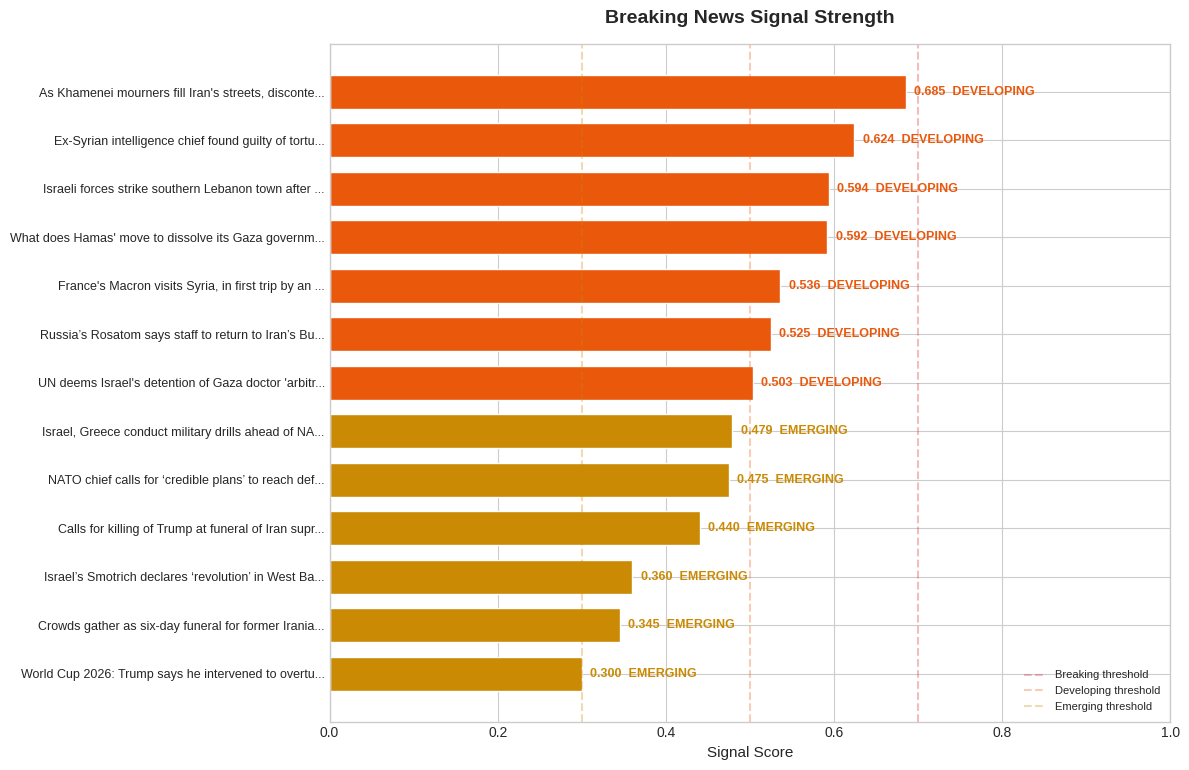

In [12]:
# ===== PHASE 5: Signal Score Bar Chart =====

fig, ax = plt.subplots(figsize=(12, max(4, len(clusters) * 0.6)))

sorted_clusters = list(reversed(clusters))
labels = []
scores = []
colors = []

for cl in sorted_clusters:
    short_title = cl["representative"][:50]
    if len(cl["representative"]) > 50:
        short_title += "..."
    labels.append(short_title)
    scores.append(cl["signal_score"])
    colors.append(signal_color(cl["signal_score"]))

y_pos = range(len(labels))
bars = ax.barh(y_pos, scores, color=colors, edgecolor="white", height=0.7)

for bar, score, cl in zip(bars, scores, sorted_clusters):
    label = signal_label(score)
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{score:.3f}  {label}",
            va="center", fontsize=9, fontweight="bold",
            color=signal_color(score))

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("Signal Score", fontsize=11)
ax.set_xlim(0, 1.0)
ax.set_title("Breaking News Signal Strength", fontsize=14, fontweight="bold", pad=15)
ax.axvline(x=0.7, color="#DC2626", linestyle="--", alpha=0.3, label="Breaking threshold")
ax.axvline(x=0.5, color="#EA580C", linestyle="--", alpha=0.3, label="Developing threshold")
ax.axvline(x=0.3, color="#CA8A04", linestyle="--", alpha=0.3, label="Emerging threshold")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

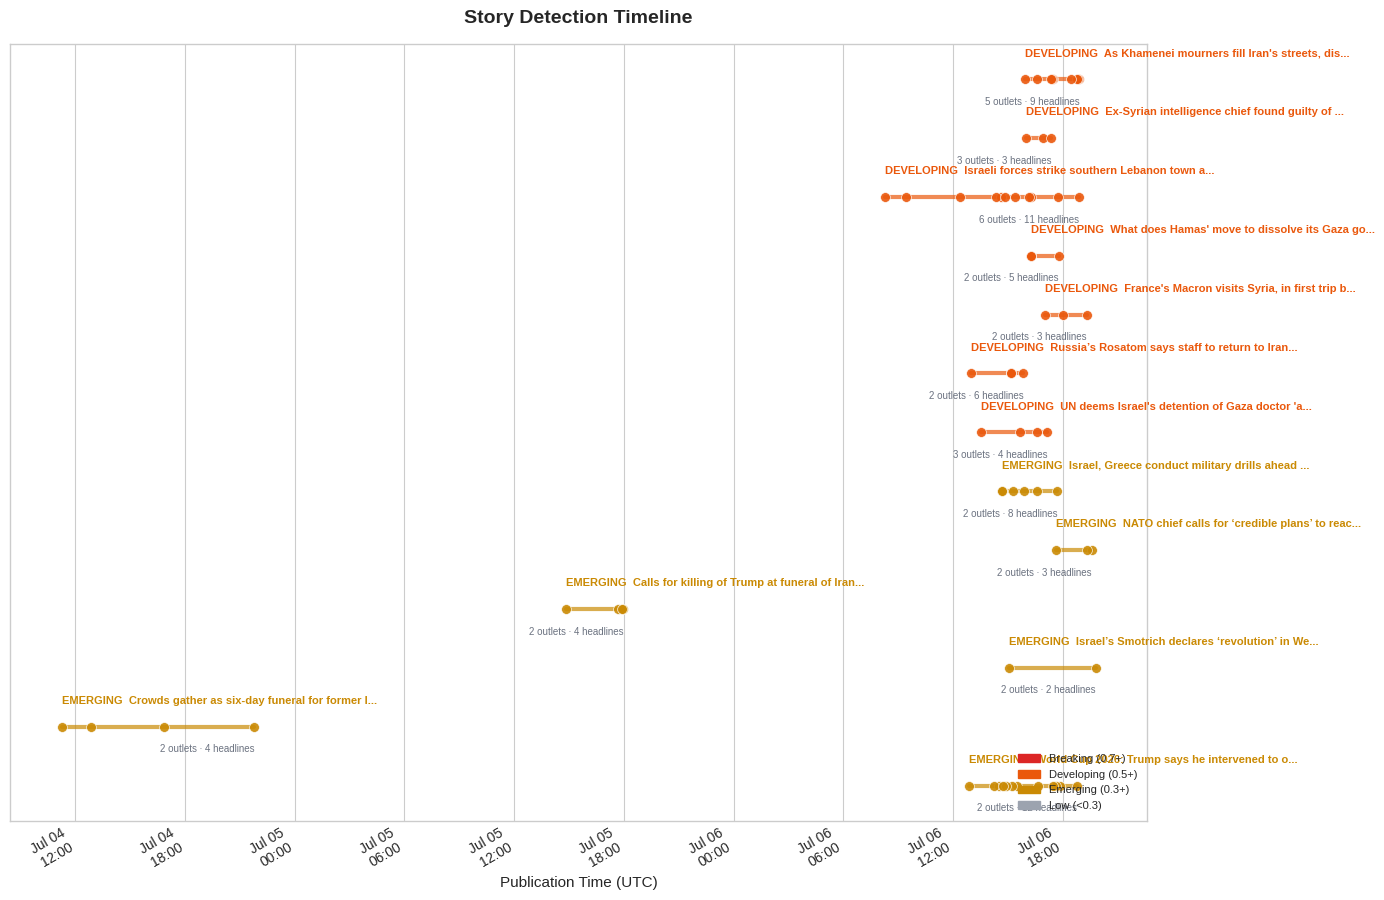

In [13]:
# ===== PHASE 5: Story Timeline =====

fig, ax = plt.subplots(figsize=(14, max(4, len(clusters) * 0.7)))

for i, cl in enumerate(clusters):
    y = len(clusters) - 1 - i
    color = signal_color(cl["signal_score"])

    ax.plot(
        [cl["earliest"], cl["latest"]], [y, y],
        color=color, linewidth=3, solid_capstyle="round", alpha=0.7
    )

    member_times = headlines.loc[cl["headline_indices"]]["published"]
    ax.scatter(
        member_times, [y] * len(member_times),
        s=50, color=color, edgecolors="white", linewidth=0.5,
        zorder=5, alpha=0.9
    )

    short_title = cl["representative"][:45]
    if len(cl["representative"]) > 45:
        short_title += "..."
    label_text = f"{signal_label(cl['signal_score'])}  {short_title}"
    ax.text(
        cl["earliest"], y + 0.35, label_text,
        fontsize=8, fontweight="bold", color=color, va="bottom"
    )

    ax.text(
        cl["latest"], y - 0.3,
        f"{cl['num_outlets']} outlets · {cl['num_headlines']} headlines",
        fontsize=7, color="#6B7280", va="top", ha="right"
    )

ax.set_yticks([])
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%H:%M"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
fig.autofmt_xdate()
ax.set_title("Story Detection Timeline", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Publication Time (UTC)", fontsize=11)

legend_patches = [
    mpatches.Patch(color="#DC2626", label="Breaking (0.7+)"),
    mpatches.Patch(color="#EA580C", label="Developing (0.5+)"),
    mpatches.Patch(color="#CA8A04", label="Emerging (0.3+)"),
    mpatches.Patch(color="#9CA3AF", label="Low (<0.3)"),
]
ax.legend(handles=legend_patches, loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1370/1986476052.py:45: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color="#F3F4F6", label="Not covered", edgecolor="#D1D5DB"),


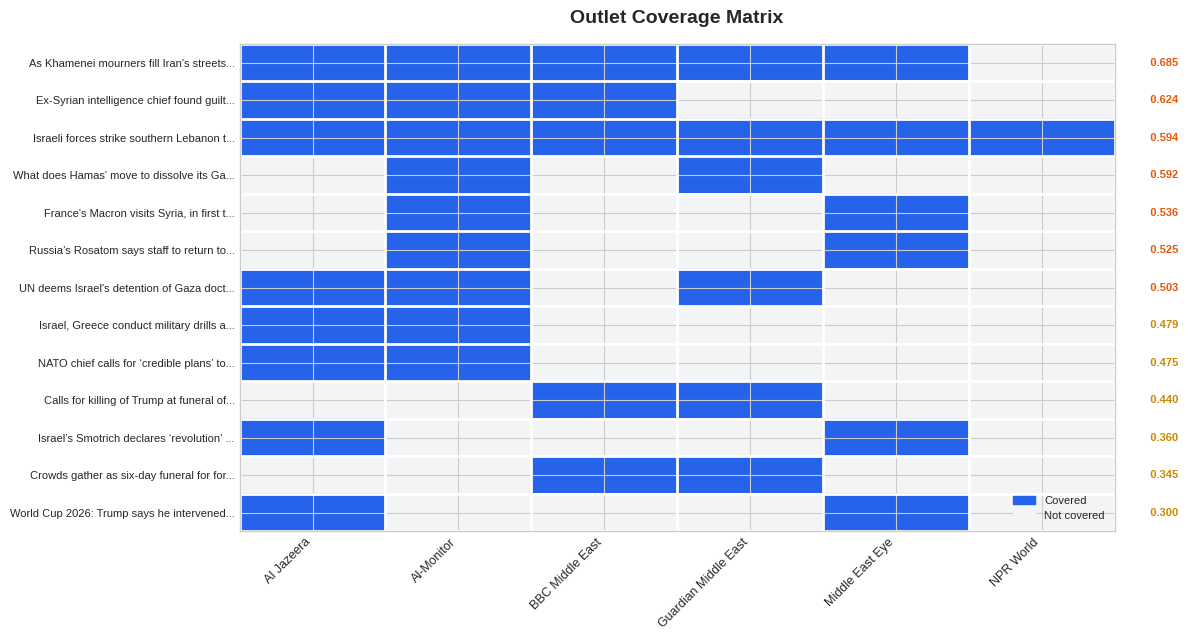

In [14]:
# ===== PHASE 5: Outlet Coverage Heatmap =====

all_outlets = sorted(headlines["outlet"].unique())
heatmap_data = []

for cl in clusters:
    row = []
    member_outlets = set(headlines.loc[cl["headline_indices"]]["outlet"])
    for outlet in all_outlets:
        row.append(1 if outlet in member_outlets else 0)
    heatmap_data.append(row)

heatmap_df = pd.DataFrame(
    heatmap_data,
    columns=all_outlets,
    index=[cl["representative"][:40] + "..." if len(cl["representative"]) > 40
           else cl["representative"] for cl in clusters]
)

fig, ax = plt.subplots(figsize=(12, max(4, len(clusters) * 0.5)))
cmap = plt.cm.colors.ListedColormap(["#F3F4F6", "#2563EB"])
im = ax.imshow(heatmap_df.values, cmap=cmap, aspect="auto", interpolation="nearest")

ax.set_xticks(range(len(all_outlets)))
ax.set_xticklabels(all_outlets, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(heatmap_df)))
ax.set_yticklabels(heatmap_df.index, fontsize=8)

for i, cl in enumerate(clusters):
    ax.text(
        len(all_outlets) - 0.3, i,
        f"  {cl['signal_score']:.3f}",
        va="center", ha="left", fontsize=8,
        fontweight="bold", color=signal_color(cl["signal_score"])
    )

for i in range(len(all_outlets) + 1):
    ax.axvline(i - 0.5, color="white", linewidth=2)
for i in range(len(clusters) + 1):
    ax.axhline(i - 0.5, color="white", linewidth=2)

ax.set_title("Outlet Coverage Matrix", fontsize=14, fontweight="bold", pad=15)
legend_patches = [
    mpatches.Patch(color="#2563EB", label="Covered"),
    mpatches.Patch(color="#F3F4F6", label="Not covered", edgecolor="#D1D5DB"),
]
ax.legend(handles=legend_patches, loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

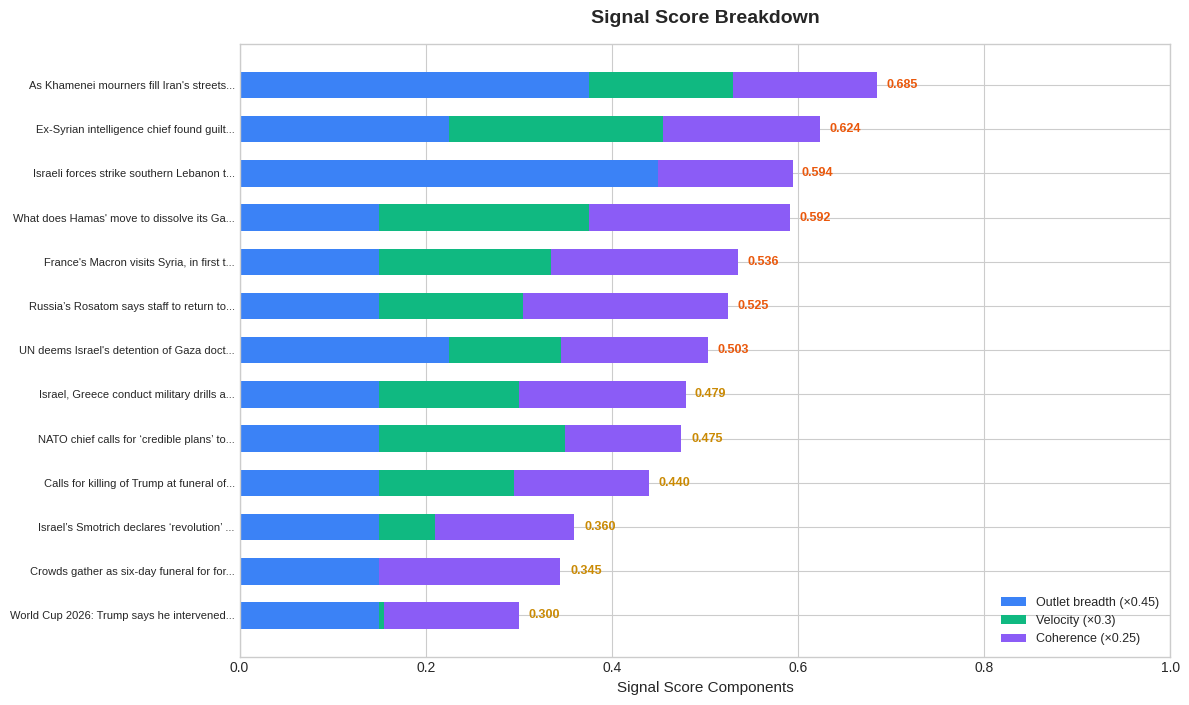

In [15]:
# ===== PHASE 5: Score Breakdown Stacked Bar =====

fig, ax = plt.subplots(figsize=(12, max(4, len(clusters) * 0.55)))

sorted_cl = list(reversed(clusters))
labels = []
outlet_vals = []
velocity_vals = []
coherence_vals = []

for cl in sorted_cl:
    short = cl["representative"][:40]
    if len(cl["representative"]) > 40:
        short += "..."
    labels.append(short)
    outlet_vals.append(W_OUTLETS * cl["outlet_score"])
    velocity_vals.append(W_VELOCITY * cl["velocity_score"])
    coherence_vals.append(W_COHERENCE * cl["coherence_score"])

y_pos = range(len(labels))

ax.barh(y_pos, outlet_vals, height=0.6, label=f"Outlet breadth (×{W_OUTLETS})",
        color="#3B82F6")
ax.barh(y_pos, velocity_vals, height=0.6, left=outlet_vals,
        label=f"Velocity (×{W_VELOCITY})", color="#10B981")
left2 = [o + v for o, v in zip(outlet_vals, velocity_vals)]
ax.barh(y_pos, coherence_vals, height=0.6, left=left2,
        label=f"Coherence (×{W_COHERENCE})", color="#8B5CF6")

for i, cl in enumerate(sorted_cl):
    total = cl["signal_score"]
    ax.text(total + 0.01, i, f"{total:.3f}",
            va="center", fontsize=9, fontweight="bold",
            color=signal_color(total))

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("Signal Score Components", fontsize=11)
ax.set_xlim(0, 1.0)
ax.set_title("Signal Score Breakdown", fontsize=14, fontweight="bold", pad=15)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

In [16]:
# ===== PHASE 5: Final Summary =====

print(f"{'='*70}")
print(f"  BREAKING NEWS SIGNAL DETECTOR — FINAL REPORT")
print(f"  Run: {datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M UTC')}")
print(f"  {len(headlines)} headlines from {TOTAL_OUTLETS} outlets")
print(f"  Model: all-MiniLM-L6-v2 (sentence embeddings)")
print(f"  Parameters: similarity ≥{SIMILARITY_THRESHOLD}  |  "
      f"window ≤{TIME_WINDOW_HRS}hrs  |  "
      f"resolution {RESOLUTION}")
print(f"{'='*70}\n")

for i, cl in enumerate(clusters):
    emoji = signal_emoji(cl["signal_score"])
    label = signal_label(cl["signal_score"])

    print(f"  {emoji} #{i+1}  {label} ({cl['signal_score']:.3f})")
    print(f"     {cl['representative']}")
    print(f"     {cl['num_outlets']} outlets · {cl['num_headlines']} headlines · "
          f"{cl['time_span_hrs']}h span")
    print(f"     Sources: {', '.join(cl['outlets'])}")
    print()

  BREAKING NEWS SIGNAL DETECTOR — FINAL REPORT
  Run: 2026-07-06 19:57 UTC
  134 headlines from 6 outlets
  Model: all-MiniLM-L6-v2 (sentence embeddings)
  Parameters: similarity ≥0.45  |  window ≤6hrs  |  resolution 1.5

  🟠 #1  DEVELOPING (0.685)
     As Khamenei mourners fill Iran's streets, discontent still simmers
     5 outlets · 9 headlines · 2.9h span
     Sources: Al Jazeera, Al-Monitor, BBC Middle East, Guardian Middle East, Middle East Eye

  🟠 #2  DEVELOPING (0.624)
     Ex-Syrian intelligence chief found guilty of torture and sexual abuse by Austrian court
     3 outlets · 3 headlines · 1.4h span
     Sources: Al Jazeera, Al-Monitor, BBC Middle East

  🟠 #3  DEVELOPING (0.594)
     Israeli forces strike southern Lebanon town after funeral attack
     6 outlets · 11 headlines · 10.6h span
     Sources: Al Jazeera, Al-Monitor, BBC Middle East, Guardian Middle East, Middle East Eye, NPR World

  🟠 #4  DEVELOPING (0.592)
     What does Hamas' move to dissolve its Gaza governme